In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Подготовка данных

Чтение csv

In [43]:
df = pd.read_csv('iris.csv', sep=',')
df

,Sepal.L,Sepal.W,Petal.L,Petal.W,Kind
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


Удаление лишних столбцов

In [33]:
df['type'] = df['Kind'].map({'Iris-setosa': 1, 'Iris-versicolor': -1, 'Iris-virginica': -1})
df = df.drop('Kind', axis=1)
df = df.drop('Petal.L', axis=1)
df = df.drop('Petal.W', axis=1)
df

,Sepal.L,Sepal.W,type
0,5.1,3.5,1
1,4.9,3.0,1
2,4.7,3.2,1
3,4.6,3.1,1
4,5.0,3.6,1
...,...,...,...
145,6.7,3.0,-1
146,6.3,2.5,-1
147,6.5,3.0,-1
148,6.2,3.4,-1


Разделение выборки на тестовую и обучающую

In [34]:
X = df.drop('type', axis=1)
y = df['type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)
X_train.reset_index(drop=True)
y_train.reset_index(drop=True)
X_test.reset_index(drop=True)
y_test.reset_index(drop=True)
len(X_train), len(X_test), len(y_train), len(y_test)

(100, 50, 100, 50)

# Создание модели SVM

In [86]:
class SVM:
    def __init__(self, kernel='linear', gamma=1.0, alpha=0.1, c=0, learning_rate=0.01, num_epochs=1000):
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.weights = None
        self.bias = None
        self.kernel = kernel
        self.gamma = gamma
        self.alpha = alpha
        self.c = c

    def kernel_function(self, x, x_prime):
        if self.kernel == 'linear':
            return np.dot(x, x_prime)
        elif self.kernel == 'quadratic':
            return (np.dot(x, x_prime) + self.c) ** 2
        elif self.kernel == 'sigmoid':
            return np.tanh(self.alpha * np.dot(x, x_prime) + self.c)
        raise Exception('func not found')

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_samples)
        self.bias = 0

        # Gram matrix
        K = np.zeros((num_samples, num_samples))
        for i in range(num_samples):
            for j in range(num_samples):
                K[i,j] = self.kernel_function(X[i], X[j])

        for epoch in range(self.num_epochs):
            for i in range(num_samples):
                if y[i] * (np.dot(K[i], self.weights) + self.bias) < 1:
                    self.weights += self.learning_rate * (y[i] * K[i] - 2 * (1 / self.num_epochs) * self.weights)
                    self.bias += self.learning_rate * y[i]

    def predict(self, X):
        y_pred = []
        for i in range(len(X)):
            prediction = np.sign(np.dot(self.weights, [self.kernel_function(x_i, X[i]) for x_i in X_train.values]) + self.bias)
            y_pred.append(prediction)
        return np.array(y_pred)

# Обучение

In [88]:
def cal_accuracy(y_test, x_test, svm_e: SVM):
    y_predict = svm_e.predict(x_test)
    count_correct = 0
    for idx in range(len(y_test)):
        if y_test[idx] == y_predict[idx]:
            count_correct += 1

    return count_correct / len(y_test)

### линейное

In [89]:
svm = SVM(kernel='linear')
for i in range(3):
    svm.fit(X_train.values, y_train.values)

accuracy_test = cal_accuracy(y_test.values,X_test.values, svm)
accuracy_train = cal_accuracy(y_train.values,X_train.values, svm)

x_line = np.linspace(4, 8, 500)
y_line = np.linspace(2, 5, 500)
z_line = []

for x in x_line:
    for y in y_line:
        z_line.append(svm.predict(np.array([[x,y]])))

z_line = np.array(z_line)
z_line = z_line.reshape((500,500))

plt.contourf(x_line, y_line, z_line,alpha=0.3, colors=['red','blue'])
plt.scatter(X_train[y_train == 1]['Sepal.L'], X_train[y_train == 1]['Sepal.W'], color='red', label='Setosa')
plt.scatter(X_train[y_train == -1]['Sepal.L'], X_train[y_train == -1]['Sepal.W'], color='blue', label='non-Setosa')
plt.ylabel('Sepal.W')
plt.xlabel('Sepal.L')
plt.legend()

accuracy_test, accuracy_train, svm.weights, svm.bias

ValueError: shapes (100,) and (50,) not aligned: 100 (dim 0) != 50 (dim 0)

### квадратичное

(0.98,
 0.98,
 array([ -349.11608102, -1311.97576675,   190.38876632,  -396.98797578,
         -581.54705605,  -457.48682417,    46.01188752,  -824.15263359,
         -440.63588392,  -342.58549541,   507.34754281,   740.80171339,
         -245.7490906 ,  -122.84541642,   110.77842982,  -287.77686609,
          -71.6406027 ,  -597.53381117,  1255.92685173,   824.71550357,
         -653.59901143,   173.21169115,   827.05382655,  2056.53874899,
         -503.04719192,   821.75540303,    54.04711909,   -58.72788063,
         1162.00477552, -1098.01871892,   -11.49314125,    52.47554543,
          628.72828772,  -797.92645736,  -364.63310145,  -342.58549541,
         -528.37200006,  1467.62889372,  1088.05176285,   -76.92984583,
          -79.60107189,    42.67364059,   387.73248213,   584.63848226,
         -412.08608339,  -503.04719192,  1005.43054605,  1252.93422846,
         -879.52437368,  1087.81828392,   788.77963526,  1477.57320198,
         -504.36079007,  -290.2611064 , -1222.2239

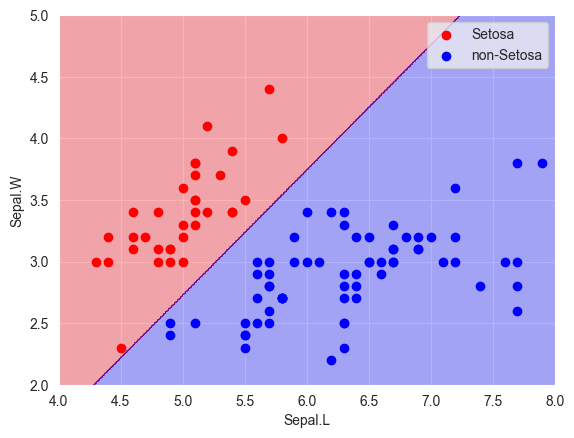

In [54]:
svm = SVM(kernel='quadratic')
for i in range(3):
    svm.fit(X_train.values, y_train.values)

accuracy_test = cal_accuracy(y_test.values,X_test.values, svm)
accuracy_train = cal_accuracy(y_train.values,X_train.values, svm)

x_line = np.linspace(4,8,500)
y_line = np.linspace(2,5,500)
z_line = []
for x in x_line:
    for y in y_line:
        z_line.append(svm.predict(np.array([[x,y]])))

z_line = np.array(z_line)
z_line = z_line.reshape((500,500))

plt.contourf(x_line, y_line, z_line,alpha=0.3, colors=['red','blue'])
plt.scatter(X_train[y_train == 1]['Sepal.L'], X_train[y_train == 1]['Sepal.W'], color='red', label='Setosa')
plt.scatter(X_train[y_train == -1]['Sepal.L'], X_train[y_train == -1]['Sepal.W'], color='blue', label='non-Setosa')
plt.ylabel('Sepal.W')
plt.xlabel('Sepal.L')
plt.legend()

accuracy_test, accuracy_train, svm.weights, svm.bias

# Доп тест

In [55]:
df_dop = pd.read_csv('dop.csv')
df_dop = df_dop.drop('Petal.L', axis=1)
df_dop = df_dop.drop('Petal.W', axis=1)
df_dop

,Sepal.L,Sepal.W
0,6.0,2.9
1,5.2,3.0
2,5.7,2.8
3,5.4,3.4
4,6.7,3.3
5,5.9,3.1
6,5.9,2.9
7,6.5,3.0
8,5.5,2.9
9,6.2,2.9


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


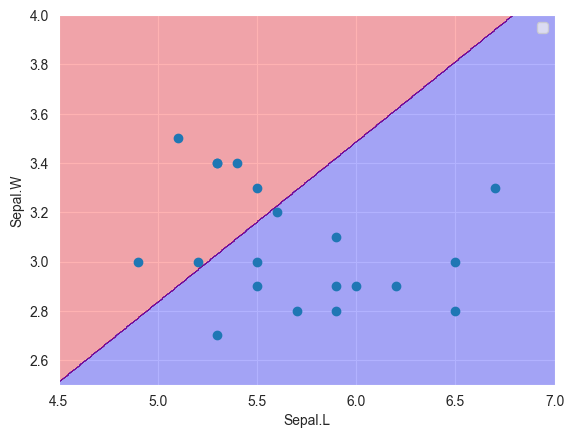

In [57]:
x_line = np.linspace(4.5,7,500)
y_line = np.linspace(2.5,4,500)
z_line = []
for x in x_line:
    for y in y_line:
        z_line.append(svm.predict(np.array([[x,y]]), line=False))

z_line = np.array(z_line)
z_line = z_line.reshape((500,500))

plt.contourf(x_line, y_line, z_line,alpha=0.3, colors=['red','blue'])
plt.scatter(df_dop['Sepal.L'], df_dop['Sepal.W'])
plt.ylabel('Sepal.W')
plt.xlabel('Sepal.L')
plt.legend()

In [72]:
result = svm.predict(df_dop.values, line=False)
for i in range(len(result)):
    if (result[i] == 1):
        print(df_dop.values[i],'Setosa')
    else:
        print(df_dop.values[i],'non-Setosa')

[6.  2.9] non-Setosa
[5.2 3. ] Setosa
[5.7 2.8] non-Setosa
[5.4 3.4] Setosa
[6.7 3.3] non-Setosa
[5.9 3.1] non-Setosa
[5.9 2.9] non-Setosa
[6.5 3. ] non-Setosa
[5.5 2.9] non-Setosa
[6.2 2.9] non-Setosa
[5.5 3. ] non-Setosa
[4.9 3. ] Setosa
[5.5 3.3] Setosa
[5.1 3.5] Setosa
[5.3 3.4] Setosa
[5.9 2.8] non-Setosa
[5.3 3.4] Setosa
[6.5 2.8] non-Setosa
[5.6 3.2] Setosa
[5.3 2.7] non-Setosa
